# A01 - Your Town, Your Agent, Your Map

*Released Wednesday 9 September, due Wednesday 23 September. Ten points, marked complete or incomplete.*

In the first precept we made a map of Princeton, proved it was the right Princeton, and had an agent answer a question we had first attempted ourselves. Now you do the same for a place you actually care about.

**You do not need anything from class, from the handout, or from any other file to do this.** Everything you need is in this notebook, including the checklist you will be marked against. If you were not in the room on the ninth, you are not at a disadvantage.

Before you change anything, make this notebook yours: File, then Save As, and give it a name with `-mywork` in it, for example `a01-hackl-mywork.ipynb`. Files named that way are ignored by the course repository, so nothing you write here can be overwritten when you fetch next week's material.

Budget about three hours, spread over more than one sitting.

## What you are marked against

This is the whole grading contract. Work that meets every line is complete and earns the full ten points. Tick them yourself before you submit, because that is what a specification is for.

- [ ] The notebook runs from top to bottom without errors after Restart and Run All
- [ ] A place of your own choosing is used, or the Princeton fallback is used with a different anchor and amenity than the worked example
- [ ] Both maps are present, the static one and the interactive one
- [ ] The walk radius question is answered for a point you chose, computed in a coordinate system measured in metres
- [ ] The three checks are run on your own data, with one sentence of interpretation each
- [ ] A written specification is included for the step you delegated
- [ ] The audit of the agent's work names what you checked, or an honest report says what you tried instead
- [ ] A few sentences interpret what you found, including what the data misses
- [ ] The AI note is present, three lines, at the end

If something is missing when I check, you get feedback and two weeks to add it. Submit on time and that safety net applies; nothing can be revised after Dean's Date.

## Settings

This is the only cell you have to change. Everything below reads from it, so once you have set your place here you can run the whole notebook from the top.

Leave `USE_LIVE_OSM` as `False` for now. Read the next section before you switch it on.

In [1]:
import json

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")

In [2]:
PLACE = "Princeton, New Jersey"        # the place you are mapping
USE_LIVE_OSM = False                   # True fetches your own place from OpenStreetMap

BOUNDARY_FILE = "data/princeton_boundary.geojson"   # used when USE_LIVE_OSM is False
FOOD_FILE = "data/princeton_food.geojson"

ANCHOR_NAME = "Nassau Hall"            # the point you measure from
ANCHOR_LAT = 40.34877
ANCHOR_LON = -74.65927

WALK_RADIUS_M = 400                    # how far a short walk is, in metres

## Task A, part one: getting data for your place

There are two lanes through this assignment and **both are fully accepted**.

**The offline lane**, which is what you have right now. A pinned snapshot of Princeton sits in the `data` folder beside this notebook: the municipal boundary as published by the State of New Jersey, and 92 places to eat taken from OpenStreetMap on 2026-08-29. If you take this lane, you must choose an anchor point other than Nassau Hall and look at one kind of amenity rather than all six, so that your work is your own.

**The live lane**, which fetches a place you choose. Set `USE_LIVE_OSM = True` above, put your town in `PLACE`, and the cells below will go and get it.

A word about where that data comes from, because it shapes what you can say about it. **OpenStreetMap** is a map of the world built by volunteers, in the same spirit as Wikipedia. Anybody can add a building or a restaurant. The consequence is that its gaps are not random: busy places get mapped, quiet ones do not, and a town where somebody ran a mapping party looks richer than its neighbour. Whatever you conclude about your place, you are partly describing who bothered to map it. The data is licensed ODbL and requires attribution, which is why the credit travels inside the files.

Two more terms you will meet in the code. **Geocoding** is turning a name like "Heidelberg, Germany" into a shape, and it is a guess: the service picks the most likely match, and it is occasionally wrong in ways only you can spot. An **amenity tag** is OpenStreetMap's own vocabulary for what kind of place something is, which is why we have to ask for `restaurant` and `cafe` by their exact names.

Note that live services fail. Yours may time out or return nothing, and that is not your fault. If it does, set `USE_LIVE_OSM` back to `False` and take the offline lane; you lose no marks whatsoever.

The pattern below is worth understanding, because it is how professional work with live data is done. We **fetch once, save the result, and then read the saved copy**. A live service is not a dataset. A notebook that re-fetches every time cannot be re-run next week, cannot be graded, and cannot be reproduced by anybody else.

The cell below runs only if you set `USE_LIVE_OSM = True`. The indented lines belong to the `if`, i.e. they happen only when the condition holds:

In [3]:
if USE_LIVE_OSM:
    import osmnx as ox

    ox.settings.requests_timeout = 300

    boundary = ox.geocode_to_gdf(PLACE)
    places = ox.features_from_polygon(
        boundary.geometry.iloc[0],
        {"amenity": ["restaurant", "cafe", "fast_food", "bar", "pub", "ice_cream"]},
    )
    print(f"fetched {len(places)} places for {PLACE}")

What comes back from OpenStreetMap needs tidying, and the reason is worth knowing.

A restaurant can be mapped in two ways: as a single dot, or as the outline of the building it occupies. Both are correct, and both are in the data. To count places we want one dot each, so we replace every outline with its **centroid**, i.e. the balance point of the shape. The centroid of a dot is the dot itself, so this is safe to do to everything.

There is a trap here that this course cares about a great deal. A centroid is a geometric calculation, and geometry must never be done in degrees. So we move the data into a coordinate system measured in metres first, take the centroids there, and move back.

Which metric system? For Princeton we used `EPSG:26918`. For your town that would be wrong. Rather than looking it up, we ask the data: `estimate_utm_crs()` reads the bounds of your own layer and returns the metric system designed for that strip of the world.

Note that it may hand you `EPSG:32618` where the precept used `EPSG:26918`. Those two are the same strip of the world measured in metres, differing only in the reference model of the Earth's shape, and either is right here. Noticing the difference and saying which you used is exactly the care this assignment is looking for.

In [4]:
if USE_LIVE_OSM:
    places = places.reset_index()
    for column in ("name", "amenity"):
        if column not in places.columns:   # a small town may have none of these tagged
            places[column] = None
    places = places[["name", "amenity", "geometry"]]

    metric = places.estimate_utm_crs()
    places["geometry"] = places.to_crs(metric).geometry.centroid.to_crs(places.crs)

    boundary["name"] = PLACE
    boundary = boundary[["name", "geometry"]]

    BOUNDARY_FILE = "data/my_boundary.geojson"
    FOOD_FILE = "data/my_food.geojson"
    boundary.to_file(BOUNDARY_FILE, driver="GeoJSON")
    places.to_file(FOOD_FILE, driver="GeoJSON")
    print(f"saved {BOUNDARY_FILE} and {FOOD_FILE}")

From here on, both lanes are identical. Whichever one you took, the next cell reads two files off the disk, and everything after it works the same way:

In [5]:
boundary = gpd.read_file(BOUNDARY_FILE)
food = gpd.read_file(FOOD_FILE)

print(f"{PLACE}: {len(boundary)} boundary, {len(food)} places to eat")

Princeton, New Jersey: 1 boundary, 92 places to eat


Let us look at what we have. `head` shows the first few rows, and `value_counts` tells us what is actually in a column, as opposed to what we assume is in it:

In [6]:
display(food.head(3))
food["amenity"].value_counts()

,name,amenity,geometry
0,Metro North,restaurant,POINT (-74.65398 40.33471)
1,Roots Ocean Prime,restaurant,POINT (-74.65944 40.34333)
2,Starbucks,cafe,POINT (-74.65946 40.34993)


amenity
restaurant    52
fast_food     16
cafe          15
ice_cream      6
pub            2
bar            1
Name: count, dtype: int64

That second table is your vocabulary. It lists every kind of place in your data and how many of each there are, and it is where you choose the one amenity kind you will look at if you took the offline lane.

Note whether any count surprises you. A town with two hundred restaurants and no cafes is telling you something about its mappers as much as about its high street.

## Task A, part two: two maps

Now make two maps of your place, the way we did in the precept.

**The static map** layers the boundary and the food points on one pair of axes. The pattern is: draw the boundary first and keep the drawing surface it hands back, then draw the food onto that same surface by passing `ax=ax`. Whatever is drawn last sits on top.

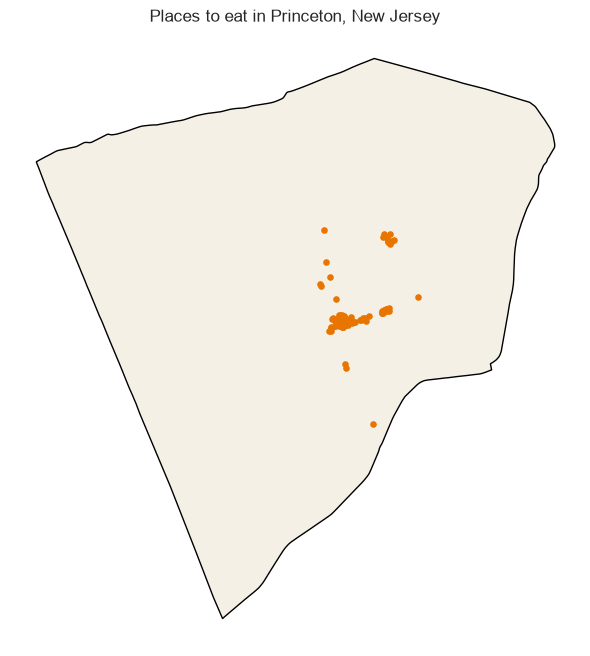

In [7]:
ax = boundary.plot(figsize=(8, 8), color="#f5f0e6", edgecolor="black", linewidth=1)
food.plot(ax=ax, color="#e77500", markersize=14)

ax.set_title(f"Places to eat in {PLACE}")
ax.set_axis_off()

**The interactive map** uses `explore` instead of `plot`, and gives you something you can zoom and click. The `tooltip` argument takes a list of column names, and those are what appear when you hover.

Note that we pass only two light layers. An interactive map writes every shape into the page, so a large layer will make your browser crawl. Rendering cost is a real design constraint.

In [8]:
webmap = boundary.explore(color="#e77500", style_kwds={"fill": False, "weight": 3})
webmap = food.explore(m=webmap, color="#e77500", tooltip=["name", "amenity"])
webmap

**Now write.** In the cell below, a few sentences on two things.

First, what does the food landscape of your place look like? Where is it concentrated, and does that match what you know about the town from having been there?

Second, and more interestingly, what is missing from the data? You know this place. Name something you are confident exists and check whether it is here. Remember that every dataset is a claim about the world made by whoever collected it, and that OpenStreetMap's gaps are not random.

*Your answer here. Double-click this cell to edit it.*

## Task B, part one: the three checks

A map that renders is not a map that is right. Before we compute anything from this data, we ask it three questions.

**One, what are the units?** `.crs` reports the coordinate reference system. `EPSG:4326` means degrees of longitude and latitude, which is what OpenStreetMap and your phone both use. Anything measured in degrees cannot give you a distance or an area directly.

**Two, where on Earth is it?** `.total_bounds` gives four numbers in the order minimum x, minimum y, maximum x, maximum y, i.e. west, south, east, north. A degree of latitude is about 111 kilometres everywhere, so you can convert a discrepancy into kilometres in your head. If the signs are wrong you will be in the wrong hemisphere, which is a surprisingly common way to lose an afternoon.

**Three, how big is it?** Area needs a metric system, so we reproject first, then divide square metres by a million to get square kilometres. An answer that is an order of magnitude out usually means you loaded the county rather than the town.

Run them on your own boundary:

In [9]:
metric = boundary.estimate_utm_crs()

print(f"crs           {boundary.crs}")
print(f"metric crs    {metric}")
print(f"total bounds  {boundary.total_bounds}")
print(f"area          {boundary.to_crs(metric).geometry.area.iloc[0] / 1e6:.2f} square kilometres")

crs           EPSG:4326
metric crs    EPSG:32618
total bounds  [-74.72214312  40.30487983 -74.61748589  40.39105584]
area          47.66 square kilometres


To judge those numbers you need something to compare them against. For Princeton, the reference values ship beside the data and can be read rather than remembered:

In [10]:
reference = json.load(open("data/ground_truth.json"))
print(json.dumps(reference["boundary"], indent=2))

{
  "area_km2": 47.66,
  "total_bounds": [
    -74.7221,
    40.3049,
    -74.6175,
    40.3911
  ]
}


**Now write.** One sentence per check, in the cell below.

What is the coordinate reference system of your data, and what are its units? Where do the bounds place your data, and is that where you expect? And does the area match the place you think you loaded, judged against something independent, for example what an encyclopedia says the town's area is? Name the source you compared against.

*Your answer here.*

## Task B, part two: the walk radius

**How many places to eat are within a `WALK_RADIUS_M` walk of your anchor point?**

Pick a point that means something to you: your old school, a flat you lived in, a corner you know. Set `ANCHOR_LAT` and `ANCHOR_LON` in the settings cell at the top. You can get both numbers by pressing and holding on the spot in your phone's map application.

**Watch the order.** Phone applications show latitude first. Code wants longitude first, because longitude is x. Getting this backwards puts your anchor in the wrong hemisphere without any error at all.

The method has four steps, and you have seen every one of them work:

1. Put both the anchor and the food into a coordinate system measured in metres.
2. Grow a circle of that radius around the anchor. That circle is called a **buffer**.
3. Ask, for every place to eat, whether it falls inside the circle.
4. Count the answers that came back true.

Step four is a `.sum()`, because Python counts `True` as one and `False` as zero.

One trap to know about before you write it. `EPSG:3857`, called Web Mercator, is measured in metres and is the most common projected system in the world, so it looks like a safe choice. At Princeton's latitude it is wrong by about thirty percent, and a buffer computed in it silently returns the wrong answer. Use the metric system your own data suggested.

Write it in the cell below. If you would rather delegate this to an agent, that is Task C, and you may do that instead of writing it yourself as long as you audit the result.

In [11]:
anchor = gpd.GeoDataFrame(
    {"name": [ANCHOR_NAME]},
    geometry=gpd.points_from_xy([ANCHOR_LON], [ANCHOR_LAT]),
    crs="EPSG:4326",
)

# Your four steps here.

**Now write.** One sentence giving your number, and one sentence on what that number does not capture.

For the second sentence, remember that we measured in a straight line while people walk along streets, so a straight line always overcounts. Think about what is between your anchor and those places: a river, a railway, a motorway, a locked campus gate.

*Your answer here.*

## Task C: delegate one step, and audit it

At least one step of this assignment must be done with a coding agent, and this is the part that matters most.

A coding agent is a program that writes code for you. This course provides one in your editor, and any other is equally acceptable. What the course grades is never which tool you used, but what it did and what you checked.

The habit that makes it work is to **write the specification before you ask**. Not because the agent needs it, but because you do: if you cannot say what a correct answer would look like, you cannot recognise one when it arrives.

Here is the template, and then the same template filled in for the walk radius question, so you can see the level of detail that works:

```text
PLACE:  which data, which file, which coordinate system
TASK:   what to compute, in what units
OUTPUT: what you want back, a number, a map, a table

Constraints: work only in this notebook, geopandas only, do not modify
earlier cells, do not install new packages.
```

```text
PLACE:  the GeoDataFrames `anchor` and `food`, already loaded in this
        notebook, both in EPSG:4326
TASK:   count the places in `food` within 400 metres of the point in
        `anchor`, measuring in a straight line, in a coordinate system
        measured in metres and appropriate for this location
OUTPUT: the count as a single integer, printed, plus a map showing the
        circle over the food points

Constraints: work only in this notebook, geopandas only, do not modify
earlier cells, do not install new packages.
```

The constraint about packages matters. Your environment is pinned so that everybody has the same one, and an agent that installs something to solve a problem has quietly made your setup different from everybody else's.

Write your own specification in the cell below, then give it to your agent.

```text
PLACE:

TASK:

OUTPUT:

Constraints: work only in this notebook, geopandas only, do not modify
earlier cells, do not install new packages.
```

In [12]:
# Paste your agent's code here. Read it before you run it.

**Now audit it,** and write what you found in the cell below.

**One, is the buffer computed in a coordinate system measured in metres, and one that is honest about distance where you are?** Degrees are the obvious trap. Web Mercator is the subtle one.

**Two, does the count match what you computed yourself, and if it differs, can you say exactly why?** A different answer is not automatically wrong. An agent that counted bakeries, or measured from a building centre rather than a door, has made a defensible choice. What is not acceptable is an answer you cannot account for.

**Three, is the circle actually on your anchor?** Draw it and look. The fastest way to catch a wrong point is to see where the circle landed.

**If you could not get any agent to work for you,** say so plainly here, describe what you tried, and show how you did the step by hand instead. An honest failure report satisfies this task completely. What does not satisfy it is silence.

*Your audit here.*

## Your AI note

Every submission in this course carries three lines: which tools you used, what they did, and what you verified yourself. It is not a confession, it is the same professional habit as citing a source. An accurate note makes the work your own in the sense of the honour pledge.

Here is a filled example, and then a blank one for you:

```text
AI note
Tools:    Antigravity with Gemini for the buffer code, spell check on the prose
They did: wrote the reprojection and buffer cell after I specified it
Verified: the CRS is metric, the count matches my own hand count of the
          markers on the map, the circle is centred on my old school and
          not on the town hall
```

```text
AI note
Tools:
They did:
Verified:
```

## Before you hand in

1. Choose **Restart Kernel and Run All Cells**, then scroll the whole notebook looking for red. Checklist item one is exactly this.
2. Re-read the checklist at the top of this notebook and tick every line.
3. Save.
4. Submit your whole `A01` folder as a single zip file on Canvas, i.e. the notebook together with its `data` folder. Right-click the folder and choose Compress on a Mac, or Send to then Compressed folder on Windows.

The folder rather than the file, because a notebook that reads data is not one file. If you took the live lane, your fetched data is in there too, and it is the only copy of what you actually used.

## Further resources

Nothing in this assignment requires anything below.

**The libraries.** The GeoPandas user guide covers everything with `gpd` in front of it: https://geopandas.org/en/stable/docs/user_guide.html. The osmnx documentation explains geocoding and feature queries in detail: https://osmnx.readthedocs.io.

**Coordinate systems.** Look up any EPSG number at https://epsg.io to see its units and the area it is meant for. Comparing https://epsg.io/4326 with the code your own data suggested is a worthwhile five minutes.

**The data.** The Princeton files are an OpenStreetMap extract, snapshot 2026-08-29, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright. The amenity vocabulary is documented at https://wiki.openstreetmap.org/wiki/Key:amenity. The municipal boundary is a public record from NJGIN Open Data: https://njogis-newjersey.opendata.arcgis.com.

**If you want a slower pass over Python itself,** the `F00` folder in this repository is our own foundations series, written for this course and using this same data.